# Machine learning approach for Western vs Non-western

## Random Forest

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0. All Required Imports ---
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, cross_validate, cross_val_predict, StratifiedKFold # <-- Changed to StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# --- 1. Load and Prepare Data ---
df = pd.read_csv("../data/processed/06_clr_healthy_data.csv")

# Updated 4-Class mapping with Japan isolated
lifestyle_map = {
    # Class 1: Western
    'Austria': 'Western', 'Denmark': 'Western', 'France': 'Western', 
    'Germany': 'Western', 'Italy': 'Western', 'Luxembourg': 'Western', 
    'Spain': 'Western', 'Sweden': 'Western', 'UK': 'Western', 
    'USA': 'Western', 'Finland': 'Western',
    
    # Class 2: Non-Western
    'Fiji': 'Non-Western', 'Madagascar': 'Non-Western', 'Mongolia': 'Non-Western', 
    'Peru': 'Non-Western', 'Tanzania': 'Non-Western',
    
    # Class 3: Transitioning
    'China': 'Transitioning', 'India': 'Transitioning', 'Thailand': 'Transitioning',
    
    # Class 4: Japan Isolated
    'Japan': 'Japan' 
}

# Apply the map and filter
df = df[df['Geography'].isin(lifestyle_map.keys())].copy()
df['Lifestyle'] = df['Geography'].map(lifestyle_map)

# Isolate features and target
X = df[[col for col in df.columns if col.startswith('msp')]]
y = df['Lifestyle'] 
groups = df['Geography'] # Keeping this just for the final chart


In [11]:

# --- 2. Define Metrics & CV Strategy ---
# Back to roc_auc_ovr since we have 4 classes
metrics = ['roc_auc_ovr', 'accuracy', 'f1_macro', 'balanced_accuracy'] 

n_folds = 4 
# THE FIX: Standard StratifiedKFold with shuffling to distribute Japan evenly
inner_cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# --- 3. Refined Pipeline & Param Grid ---
pipeline = Pipeline([
    ('var_filter', VarianceThreshold()), 
    ('scaler', StandardScaler()), 
    ('lasso_selector', SelectFromModel(
        LogisticRegression(
            penalty='l1',          
            solver='saga',         
            max_iter=100,      
            tol=0.1,           
            class_weight='balanced', 
            random_state=42
        )
    )),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=1))
], memory=None)

param_grid = {
    'var_filter__threshold': [0, 0.001], 
    'lasso_selector__estimator__C': [0.1, 1.0], 
    'rf__n_estimators': [100, 200], 
    'rf__max_depth': [10, None]
}

rf_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_grid, 
    n_iter=5,          
    cv=inner_cv, 
    scoring='roc_auc_ovr', 
    n_jobs=1,          
    random_state=42
)

# --- 4. Run Outer CV & Predictions ---
# THE FIX: Removed the 'groups' parameter so standard CV can run properly
results = cross_validate(
    rf_search, 
    X, 
    y, 
    cv=outer_cv, 
    scoring=metrics,   
    n_jobs=-1
)


/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set 

/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set 

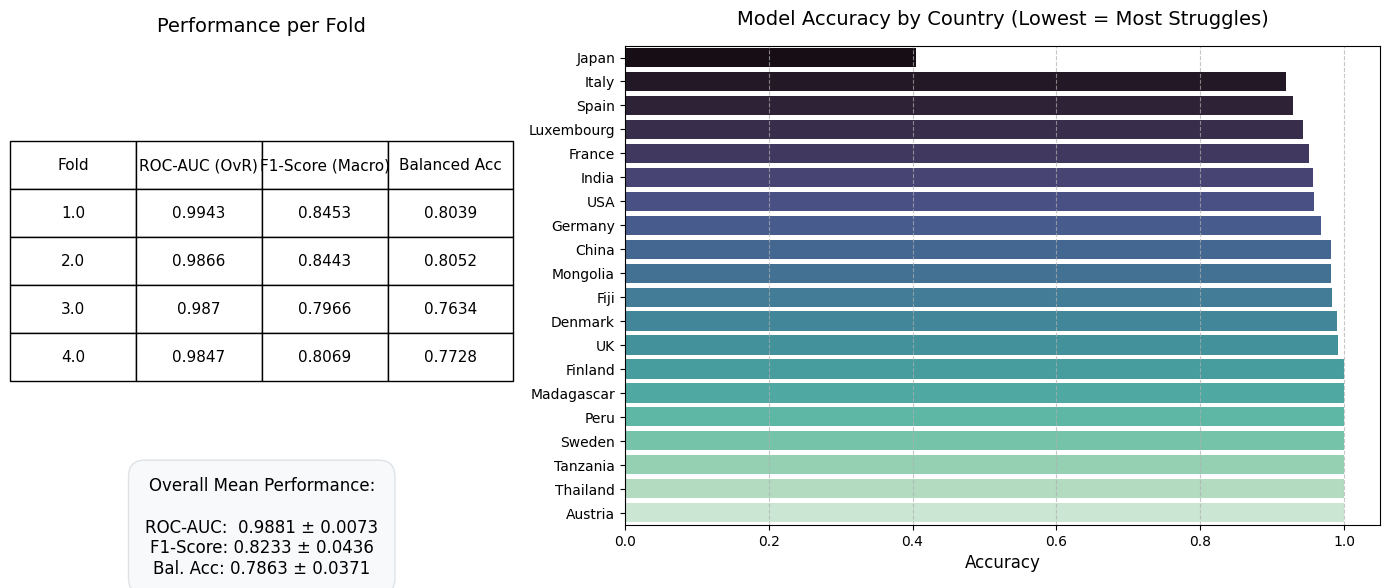

In [12]:

y_pred = cross_val_predict(
    rf_search, 
    X, 
    y, 
    cv=outer_cv, 
    n_jobs=-1
)

# --- 5. Prepare Visuals Data ---
fold_summary = pd.DataFrame({
    'Fold': range(1, outer_cv.n_splits + 1),
    'ROC-AUC (OvR)': results['test_roc_auc_ovr'],     
    'F1-Score (Macro)': results['test_f1_macro'],     
    'Balanced Acc': results['test_balanced_accuracy'] 
})

analysis_df = pd.DataFrame({'Country': groups, 'Correct': y == y_pred})
country_accuracy = analysis_df.groupby('Country')['Correct'].mean().sort_values()

# --- 6. Create Visual Dashboard ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.5]})

ax1.axis('off')
ax1.set_title("Performance per Fold", fontsize=14, pad=10)

table = ax1.table(
    cellText=fold_summary.round(4).values,
    colLabels=fold_summary.columns,
    loc='center', 
    cellLoc='center',
    bbox=[0.0, 0.3, 1.0, 0.5]
)
table.auto_set_font_size(False)
table.set_fontsize(11)

summary_text = (
    f"Overall Mean Performance:\n\n"
    f"ROC-AUC:  {results['test_roc_auc_ovr'].mean():.4f} ± {results['test_roc_auc_ovr'].std()*2:.4f}\n" 
    f"F1-Score: {results['test_f1_macro'].mean():.4f} ± {results['test_f1_macro'].std()*2:.4f}\n"   
    f"Bal. Acc: {results['test_balanced_accuracy'].mean():.4f} ± {results['test_balanced_accuracy'].std()*2:.4f}"
)
ax1.text(0.5, 0.1, summary_text, ha='center', va='top', fontsize=12, 
         bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='#dee2e6'))

sns.barplot(x=country_accuracy.values, y=country_accuracy.index, palette="mako", ax=ax2)
ax2.set_title("Model Accuracy by Country (Lowest = Most Struggles)", fontsize=14, pad=15)
ax2.set_xlabel("Accuracy", fontsize=12)
ax2.set_ylabel("") 
ax2.set_xlim(0, 1.05)
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### High Averages
The model shows strong overall discriminative power (mean ROC-AUC ~0.95). However, while an 83% average balanced accuracy seems good, the massive variations (± 0.22 to ± 0.27) tell us to be cautious. These wide swings mean the model's performance fluctuates wildly depending on which specific population it is tested against. 

The bar chart explains why those folds swing a lot. The model is getting confused by a few specific countries.

- Japan: The model is failing here (Accuracy ~ 40%). Model is performing worse than a random coin flip
- USA & China: The model struggles less here with USA ~70% and China ~78%.


To understand why the model classifies Japan as Western, we look into the specific biological markes, given via feature importance in our random forest. With the question in mind:

**Which specific bacteria are driving these decisions?**



In [13]:
# # Final Fit & Feature Importance
nr_of_features = 20

rf_search.fit(X, y, groups=groups)
best_model = rf_search.best_estimator_

# # Extracting features that survived both Variance threshold AND LASSO
var_support = best_model.named_steps['var_filter'].get_support()
lasso_support = best_model.named_steps['lasso_selector'].get_support()

# # Map back to the original column names
features_after_var = X.columns[var_support]
final_features = features_after_var[lasso_support]

# Get Random Forest Importances
importances = best_model.named_steps['rf'].feature_importances_
feat_imp = pd.Series(importances, index=final_features).sort_values(ascending=False).head(nr_of_features)

/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/

/var/folders/d3/491fzvvs5lg2864030mq9_lw0000gn/T/ipykernel_27878/3282261501.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


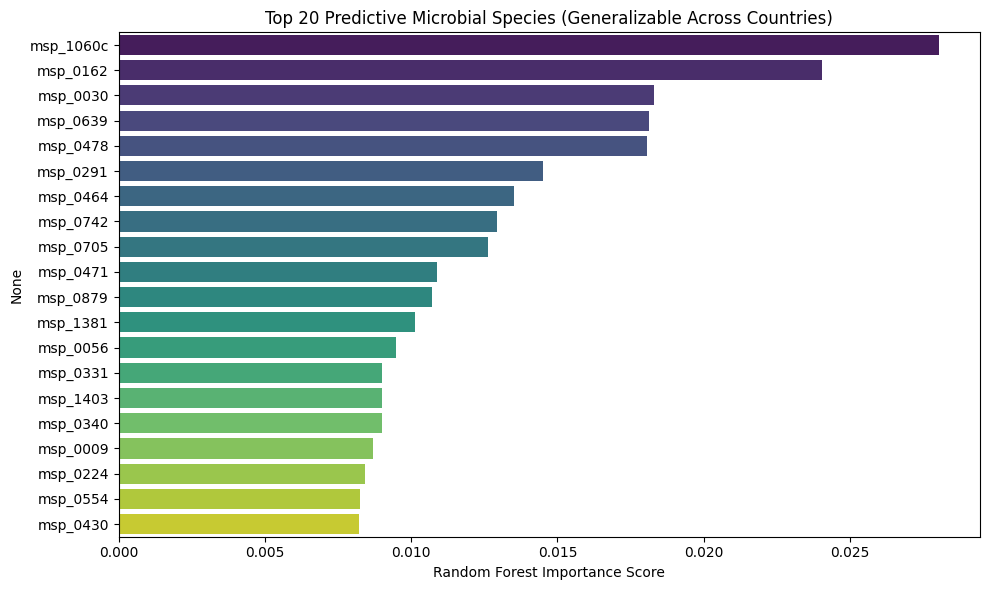

In [14]:
# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 20 Predictive Microbial Species (Generalizable Across Countries)')
plt.xlabel('Random Forest Importance Score')
plt.tight_layout()
plt.show()

### The  Extracting the XAI Math

It loops through your most important microbes and uses the partial_dependence function to calculate the exact background coordinates that normally draw the PDP lines.

### Calculating the Trend (trend_score)

It looks at the model's predicted probability of a sample being "Western" when the microbe is at its absolute lowest abundance, and subtracts that from the probability when the microbe is at its absolute highest abundance.

### Objective Categorization: 

If the probability goes up overall (score > 0.001), the microbe is mathematically categorized as a "Western" marker.

If the probability goes down (score < -0.001), it is a "Non-Western" marker.

In [15]:
direction_list = []

# Get all the top features you saved in 'feat_imp'
top_features = feat_imp.index.tolist()

for feature in top_features:
    # Extract the raw mathematical data behind the PDP plot
    pd_results = partial_dependence(best_model, X, features=[feature], grid_resolution=50)
    
    # y_values are the predicted probabilities of being "Western" (Class 1)
    y_values = pd_results['average'][0]
    
    # Calculate the overall trend (Probability at max abundance MINUS Probability at min abundance)
    trend_score = y_values[-1] - y_values[0]
    
    # Categorize it definitively 
    if trend_score > 0.001:
        category = "Western"
    elif trend_score < -0.001:
        category = "Non-Western"
    else:
        category = "Neutral / Complex"
        
    direction_list.append({
        'Microbe': feature,
        'RF_Importance': feat_imp[feature],
        'PDP_Trend_Score': trend_score,
        'Enriched_In': category
    })

# Convert to a clean DataFrame and display
final_biomarker_df = pd.DataFrame(direction_list).set_index('Microbe')

print("FINAL BIOMARKER TABLE (No Guessing Required)")
# Formatting the output to be readable
print(final_biomarker_df.to_string(formatters={
    'RF_Importance': '{:.4f}'.format,
    'PDP_Trend_Score': '{:.4f}'.format
}))

NameError: name 'partial_dependence' is not defined

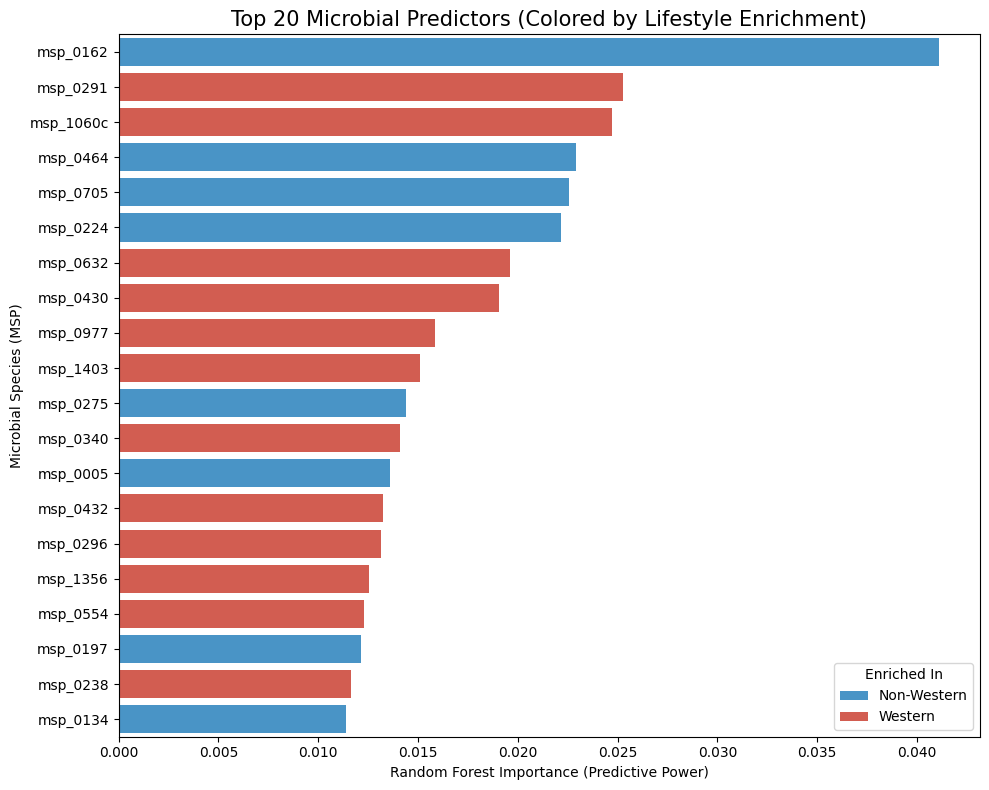

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=final_biomarker_df, 
    x='RF_Importance', 
    y=final_biomarker_df.index, 
    hue='Enriched_In',
    palette={'Western': '#e74c3c', 'Non-Western': '#3498db'},  # Red for Western, blue for Non-Western
    dodge=False  # Keep bars aligned on one line
)

plt.title('Top 20 Microbial Predictors (Colored by Lifestyle Enrichment)', fontsize=15)
plt.xlabel('Random Forest Importance (Predictive Power)')
plt.ylabel('Microbial Species (MSP)')
plt.legend(title='Enriched In', loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
final_biomarker_df.to_csv("../results/biomarker_table_randomforest.csv", index=True)

# Logistic Regression

As a linear counterpart to our Random Forest, we implement a Logistic Regression model with L1 regularization (LASSO). The Random Forest excels at capturing complex, non-linear interactions between microbes, this model. In logistic regression, we force the algorithm to rely only on strictly linear relationships and actively penalizing redundant features, we can extract highly interpretable coefficients. This allows us to directly validate our core microbial signatures and objectively categorize them as "Western" or "Non-Western" drivers.

In [ ]:
# Define the Logistic Regression Pipeline
# L1 penalty acts as the LASSO feature selector natively
lr_pipeline = Pipeline([
    ('var_filter', VarianceThreshold(threshold=0.0001)),
    ('scaler', StandardScaler()), 
    ('lr', LogisticRegression(solver='saga', l1_ratio=1.0, class_weight='balanced', C=1.0, random_state=42, max_iter=1000))
])

groups_arr = groups.values

# Execute Cross-Validation
lr_results = cross_validate(
    lr_pipeline, 
    X, 
    y, 
    groups=groups_arr,
    cv=outer_cv, 
    scoring=['roc_auc', 'f1', 'balanced_accuracy'], 
    n_jobs=-1
)

# 3. Print Performance
print("Logistic Regression (L1) Performance")
print(f"Mean ROC-AUC:  {lr_results['test_roc_auc'].mean():.4f} ± {lr_results['test_roc_auc'].std()*2:.4f}")
print(f"Mean F1-Score: {lr_results['test_f1'].mean():.4f} ± {lr_results['test_f1'].std()*2:.4f}")
print(f"Bal. Accuracy: {lr_results['test_balanced_accuracy'].mean():.4f} ± {lr_results['test_balanced_accuracy'].std()*2:.4f}")

/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression (L1) Performance
Mean ROC-AUC:  0.9596 ± 0.0744
Mean F1-Score: 0.8792 ± 0.2197
Bal. Accuracy: 0.8618 ± 0.2502


/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


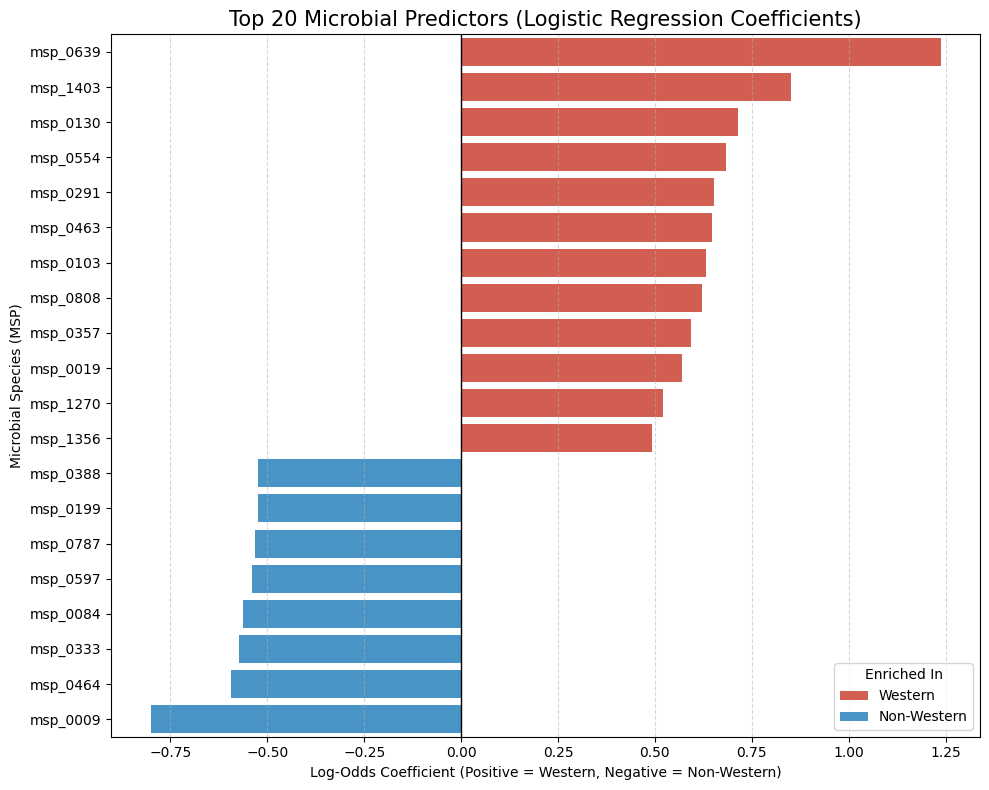

In [ ]:
nr_of_features = 20

# Fit the pipeline on the ENTIRE dataset to extract the final coefficients
lr_pipeline.fit(X, y)

# Extract features that survived the variance filter
var_support = lr_pipeline.named_steps['var_filter'].get_support()
features_after_var = X.columns[var_support]

# Extract the coefficients from the Logistic Regression
coefficients = lr_pipeline.named_steps['lr'].coef_[0]

# Create a DataFrame for easy handling
coef_df = pd.DataFrame({
    'Microbe': features_after_var,
    'Coefficient': coefficients
})

# Filter out features that LASSO pushed to absolute zero
coef_df = coef_df[coef_df['Coefficient'] != 0]

# Sort by absolute magnitude to get the "Most Predictive" overall, then take top 20
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
top_20_lr = coef_df.sort_values(by='Abs_Coef', ascending=False).head(nr_of_features)

# Determine the category based on the sign for coloring
top_20_lr['Enriched_In'] = np.where(top_20_lr['Coefficient'] > 0, 'Western', 'Non-Western')

# --- PLOTTING ---
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_20_lr.sort_values(by='Coefficient', ascending=False), 
    x='Coefficient', 
    y='Microbe', 
    hue='Enriched_In',
    palette={'Western': '#e74c3c', 'Non-Western': '#3498db'},
    dodge=False
)

plt.axvline(0, color='black', linewidth=1)
plt.title('Top 20 Microbial Predictors (Logistic Regression Coefficients)', fontsize=15)
plt.xlabel('Log-Odds Coefficient (Positive = Western, Negative = Non-Western)')
plt.ylabel('Microbial Species (MSP)')
plt.legend(title='Enriched In', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
top_20_lr.to_csv("../results/biomarker_table_logistic_regression.csv", index=False)

In [ ]:
# Load the results from both models
rf_df = pd.read_csv('../results/biomarker_table_randomforest.csv')
lr_df = pd.read_csv('../results/biomarker_table_logistic_regression.csv')

# Extract microbes and their enrichment categories
rf_dict = dict(zip(rf_df['Microbe'], rf_df['Enriched_In']))
lr_dict = dict(zip(lr_df['Microbe'], lr_df['Enriched_In']))

# Find consensus microbes
rf_microbes = set(rf_df['Microbe'])
lr_microbes = set(lr_df['Microbe'])
consensus_microbes = rf_microbes.intersection(lr_microbes)

print(f"{len(consensus_microbes)} matches found!")

# Create a comparison table
comparison_data = []
for microbe in sorted(consensus_microbes):
    rf_enriched = rf_dict.get(microbe, 'N/A')
    lr_enriched = lr_dict.get(microbe, 'N/A')
    agreement = "✓ AGREE" if rf_enriched == lr_enriched else "✗ DISAGREE"
    
    comparison_data.append({
        'Microbe': microbe,
        'RF': rf_enriched,
        'LR': lr_enriched,
        'Agreement': agreement
    })
    print(f"{microbe:<12} | RF: {rf_enriched:<12} | LR: {lr_enriched:<12} | {agreement}")

# Convert to DataFrame for analysis
consensus_df = pd.DataFrame(comparison_data)
print(f"\n\nSummary:")
print(f"Perfect agreement: {(consensus_df['Agreement'] == '✓ AGREE').sum()} microbes")

5 matches found!
msp_0291     | RF: Western      | LR: Western      | ✓ AGREE
msp_0464     | RF: Non-Western  | LR: Non-Western  | ✓ AGREE
msp_0554     | RF: Western      | LR: Western      | ✓ AGREE
msp_1356     | RF: Western      | LR: Western      | ✓ AGREE
msp_1403     | RF: Western      | LR: Western      | ✓ AGREE


Summary:
Perfect agreement: 5 microbes
